In [1]:
import pandas as pd
import requests
import json

# 1. API'den Veri Çekme (Sadece requests kullanarak)
# Kocaeli (40.85, 29.88) için 2025 saatlik veriler
url = "https://archive-api.open-meteo.com/v1/archive?latitude=40.85&longitude=29.88&start_date=2025-01-01&end_date=2025-12-31&hourly=temperature_2m,wind_speed_10m&timezone=Europe%2FIstanbul"

response = requests.get(url)
data = response.json()

# 2. JSON Verisini DataFrame'e Dönüştürme
df_weather = pd.DataFrame({
    'Tarih_Zaman': pd.to_datetime(data['hourly']['time']),
    'Sicaklik': data['hourly']['temperature_2m'],
    'Ruzgar_Hizi': data['hourly']['wind_speed_10m']
})

# 3. EPİAŞ Formatına Uygun Hale Getirme
# EPİAŞ'ta tarih 01.01.2025, saat 00:00 formatındadır.
df_weather['Tarih'] = df_weather['Tarih_Zaman'].dt.strftime('%d.%m.%Y')
df_weather['Saat'] = df_weather['Tarih_Zaman'].dt.strftime('%H:00')

print("2025 Verileri Başarıyla Çekildi!")
print(f"Toplam Satır: {len(df_weather)}")
print(df_weather.head())

2025 Verileri Başarıyla Çekildi!
Toplam Satır: 8760
          Tarih_Zaman  Sicaklik  Ruzgar_Hizi       Tarih   Saat
0 2025-01-01 00:00:00       1.8          2.4  01.01.2025  00:00
1 2025-01-01 01:00:00       1.7          2.0  01.01.2025  01:00
2 2025-01-01 02:00:00       1.4          1.8  01.01.2025  02:00
3 2025-01-01 03:00:00       1.4          1.8  01.01.2025  03:00
4 2025-01-01 04:00:00       1.3          2.3  01.01.2025  04:00


In [2]:
# 1. Dosyaları Oku
df_ptf = pd.read_csv("../data/ptf_verisi.csv", sep=";", encoding="utf-8-sig")
df_tuketim = pd.read_csv("../data/tuketim_verisi.csv", sep=";", encoding="utf-8-sig")

# 2. Sütun İsimlerindeki Boşlukları Temizle
df_ptf.columns = df_ptf.columns.str.strip()
df_tuketim.columns = df_tuketim.columns.str.strip()

# 3. EPİAŞ Verilerini Kendi İçinde Birleştir
df_epias = pd.merge(df_ptf, df_tuketim, on=['Tarih', 'Saat'])

# 4. Sayısal Verileri Temizle (Nokta ve Virgül Düzeltmesi)
df_epias['PTF (TL/MWh)'] = df_epias['PTF (TL/MWh)'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
df_epias['Tüketim Miktarı(MWh)'] = df_epias['Tüketim Miktarı(MWh)'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# 5. BÜYÜK BİRLEŞME: EPİAŞ + HAVA DURUMU
df_final = pd.merge(df_epias, df_weather, on=['Tarih', 'Saat'], how='inner')

# 6. Zaman Değişkenlerini Ekle (Model İçin Şart)
df_final['Saat'] = df_final['Saat'].str.split(':').str[0].astype(int)
df_final = df_final[['Tarih', 'Saat', 'PTF (TL/MWh)', 'Tüketim Miktarı(MWh)', 'Sicaklik', 'Ruzgar_Hizi']]

print("Eksiksiz veri seti başarıyla birleştirildi!")
print(f"Satır sayısı: {len(df_final)}")
df_final.head()

Eksiksiz veri seti başarıyla birleştirildi!
Satır sayısı: 8760


,Tarih,Saat,PTF (TL/MWh),Tüketim Miktarı(MWh),Sicaklik,Ruzgar_Hizi
0,01.01.2025,0,2494.00,32707.51,1.8,2.4
1,01.01.2025,1,1799.98,31196.05,1.7,2.0
2,01.01.2025,2,1692.99,29674.85,1.4,1.8
3,01.01.2025,3,2244.99,28490.58,1.4,1.8
4,01.01.2025,4,2400.01,28012.95,1.3,2.3


In [3]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Tarih                 8760 non-null   object 
 1   Saat                  8760 non-null   int64  
 2   PTF (TL/MWh)          8760 non-null   float64
 3   Tüketim Miktarı(MWh)  8760 non-null   float64
 4   Sicaklik              8760 non-null   float64
 5   Ruzgar_Hizi           8760 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 410.8+ KB


In [4]:
df_final.describe()

,Saat,PTF (TL/MWh),Tüketim Miktarı(MWh),Sicaklik,Ruzgar_Hizi
count,8760.000000,8760.000000,8760.000000,8760.00000,8760.000000
mean,11.500000,2619.811829,40240.840247,12.82992,8.801073
std,6.922582,801.197277,6568.838068,7.81617,6.174467
min,0.000000,0.000000,21419.130000,-7.60000,0.000000
25%,5.750000,2274.990000,34864.607500,6.87500,3.900000
50%,11.500000,2880.255000,40483.620000,12.70000,7.400000
75%,17.250000,3223.000000,44665.970000,18.70000,12.900000
max,23.000000,3400.000000,59503.670000,35.90000,31.600000


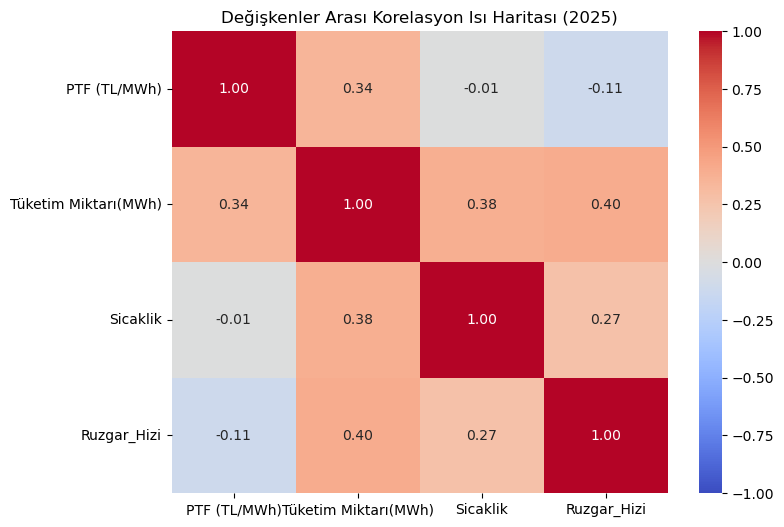

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Korelasyon hesaplanacak sütunları seçelim
cols = ['PTF (TL/MWh)', 'Tüketim Miktarı(MWh)', 'Sicaklik', 'Ruzgar_Hizi']
korelasyon_matrisi = df_final[cols].corr()

# 2. Isı haritasını çizdirelim
plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title("Değişkenler Arası Korelasyon Isı Haritası (2025)", fontsize=12)
plt.show()

In [6]:
# Tarih sütunundan Ay bilgisini (1, 2, 3... 12 diye) çekip yeni sütun yapıyoruz
df_final['Ay'] = pd.to_datetime(df_final['Tarih'], dayfirst=True).dt.month

# Kontrol edelim
df_final[['Tarih', 'Ay']].head()

,Tarih,Ay
0,01.01.2025,1
1,01.01.2025,1
2,01.01.2025,1
3,01.01.2025,1
4,01.01.2025,1


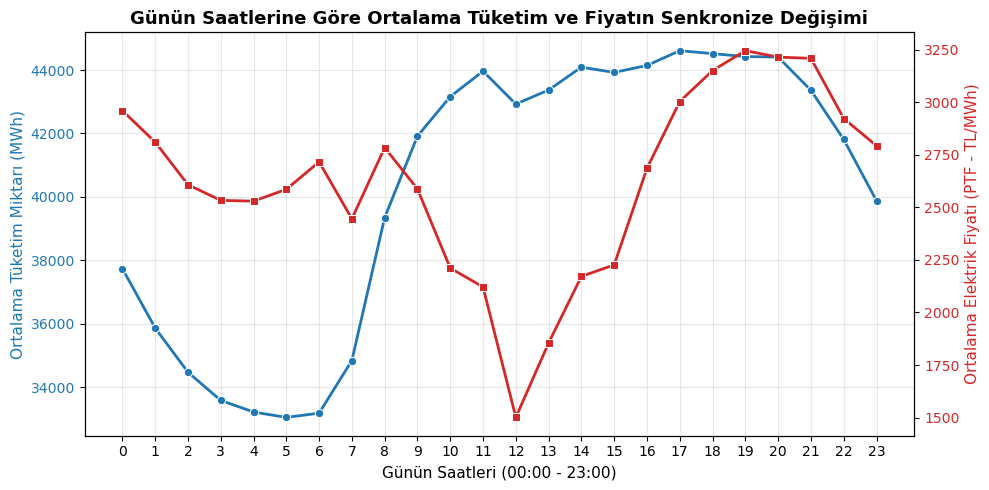

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Saatlik ortalama fiyat ve tüketim değerlerini hesaplayalım
saatlik_veriler = df_final.groupby('Saat')[['PTF (TL/MWh)', 'Tüketim Miktarı(MWh)']].mean().reset_index()

# 2. Grafiği Oluşturma (Çift Eksenli Grafik: Hem fiyat hem tüketim yan yana)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Mavi Çizgi: Tüketim Miktarı (Sol Eksen)
color = 'tab:blue'
ax1.set_xlabel('Günün Saatleri (00:00 - 23:00)', fontsize=11)
ax1.set_ylabel('Ortalama Tüketim Miktarı (MWh)', color=color, fontsize=11)
sns.lineplot(data=saatlik_veriler, x='Saat', y='Tüketim Miktarı(MWh)', ax=ax1, color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Kırmızı Çizgi: Elektrik Fiyatı - PTF (Sağ Eksen)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Ortalama Elektrik Fiyatı (PTF - TL/MWh)', color=color, fontsize=11)
sns.lineplot(data=saatlik_veriler, x='Saat', y='PTF (TL/MWh)', ax=ax2, color=color, marker='s', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Grafik Başlığı
plt.title("Günün Saatlerine Göre Ortalama Tüketim ve Fiyatın Senkronize Değişimi", fontsize=13, fontweight='bold')
plt.xticks(range(0, 24)) # X ekseninde tüm saatleri (0-23) göster

fig.tight_layout()
plt.show()

In [8]:
# 1. Sıcaklık ve Tüketim Etkileşimi (İş Mantığı: Yazın aşırı sıcakta klimalar yüklenir ve fiyat fırlar)
df_final['Sicaklik_X_Tuketim'] = df_final['Sicaklik'] * df_final['Tüketim Miktarı(MWh)']

# 2. Rüzgar Gücünün Tüketime Oranı (İş Mantığı: Rüzgar çok esiyor ama tüketim azsa, ucuz enerjiden dolayı fiyat taban yapar)
df_final['Ruzgar_Tuketim_Orani'] = df_final['Ruzgar_Hizi'] / (df_final['Tüketim Miktarı(MWh)'] + 1)

# 3. Talep Yoğunluk İndeksi (İş Mantığı: O saatteki tüketimin, o günün ortalamasına oranı. Pik saatleri çok net gösterir)
gunluk_ort_tuketim = df_final.groupby('Tarih')['Tüketim Miktarı(MWh)'].transform('mean')
df_final['Talep_Yogunluk_Indeksi'] = df_final['Tüketim Miktarı(MWh)'] / gunluk_ort_tuketim

# Eklediğimiz yeni sütunları kontrol edelim
df_final[['PTF (TL/MWh)', 'Sicaklik_X_Tuketim', 'Ruzgar_Tuketim_Orani', 'Talep_Yogunluk_Indeksi']].head()

,PTF (TL/MWh),Sicaklik_X_Tuketim,Ruzgar_Tuketim_Orani,Talep_Yogunluk_Indeksi
0,2494.00,58873.518,0.000073,0.981967
1,1799.98,53033.285,0.000064,0.936589
2,1692.99,41544.790,0.000061,0.890918
3,2244.99,39886.812,0.000063,0.855363
4,2400.01,36416.835,0.000082,0.841023


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Bağımsız Değişkenler (X) ve Bağımlı Değişken (y) Seçimi
# Modelin kullanacağı tüm akıllı ve ham özellikleri buraya topladık
özellikler = ['Saat', 'Ay', 'Tüketim Miktarı(MWh)', 'Sicaklik', 'Ruzgar_Hizi', 
              'Sicaklik_X_Tuketim', 'Ruzgar_Tuketim_Orani', 'Talep_Yogunluk_Indeksi']

X = df_final[özellikler]
y = df_final['PTF (TL/MWh)']

# 2. Veriyi %80 Eğitim, %20 Test olarak bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Optimize Edilmiş Random Forest Modelini Eğitme
print("--- Güçlendirilmiş Model Eğitiliyor (Bu işlem birkaç saniye sürebilir) ---")
# n_estimators=200: Daha kararlı tahminler için ağaç sayısını artırdık
# min_samples_split=5: Ezberlemeyi (overfitting) önlemek için optimize ettik
model_gelişmiş = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42)
model_gelişmiş.fit(X_train, y_train)

# 4. Test Seti ile Tahmin Yapma
y_pred = model_gelişmiş.predict(X_test)

# 5. Model Başarı Metriklerinin Hesaplanması
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n--- OPTİMİZE EDİLMİŞ MODEL SONUÇLARI ---")
print(f"Modelin Açıklayıcılık Oranı (R2 Skoru): %{r2*100:.2f}")
print(f"Ortalama Mutlak Hata (MAE): {mae:.2f} TL")

--- Güçlendirilmiş Model Eğitiliyor (Bu işlem birkaç saniye sürebilir) ---

--- OPTİMİZE EDİLMİŞ MODEL SONUÇLARI ---
Modelin Açıklayıcılık Oranı (R2 Skoru): %78.83
Ortalama Mutlak Hata (MAE): 240.14 TL


C:\Users\EXCALIBUR\AppData\Local\Temp\ipykernel_4800\3406608266.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem Düzeyi', y='Öznitelik', data=önem_df, palette='viridis')


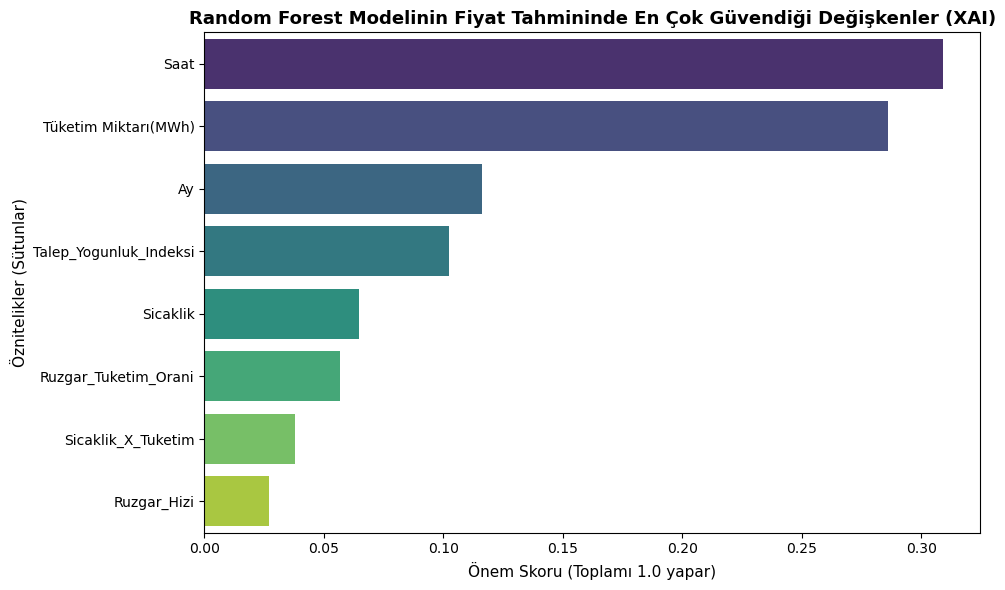

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Modelin öznitelik önem derecelerini alalım
önem_dereceleri = model_gelişmiş.feature_importances_

# 2. Bunları daha rahat görmek için bir DataFrame haline getirelim
önem_df = pd.DataFrame({
    'Öznitelik': özellikler,
    'Önem Düzeyi': önem_dereceleri
}).sort_values(by='Önem Düzeyi', ascending=False) # Büyükten küçüğe sırala

# 3. Grafik Çizimi
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Düzeyi', y='Öznitelik', data=önem_df, palette='viridis')

# Grafik Başlık ve Etiketleri
plt.title('Random Forest Modelinin Fiyat Tahmininde En Çok Güvendiği Değişkenler (XAI)', fontsize=13, fontweight='bold')
plt.xlabel('Önem Skoru (Toplamı 1.0 yapar)', fontsize=11)
plt.ylabel('Öznitelikler (Sütunlar)', fontsize=11)

plt.tight_layout()
plt.show()



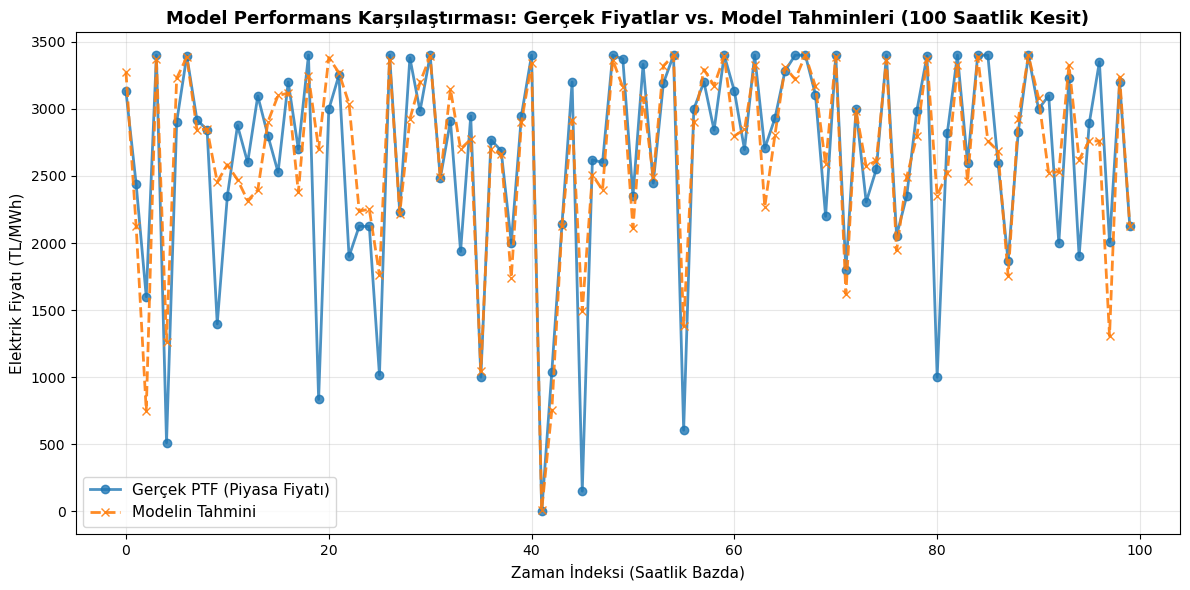

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Gerçek değerleri ve tahminleri karşılaştırmak için bir araya getirelim
# Test setinden ardışık 100 saatlik bir kesit alıyoruz (Grafik net okunsun diye)
kesit_adet = 100
y_test_kesit = y_test.iloc[:kesit_adet].values
y_pred_kesit = y_pred[:kesit_adet]

# 2. Grafik Çizimi
plt.figure(figsize=(12, 6))

# Gerçek Fiyat Çizgisi (Mavi)
plt.plot(y_test_kesit, label='Gerçek PTF (Piyasa Fiyatı)', color='tab:blue', linewidth=2, marker='o', alpha=0.8)

# Modelin Tahmin Çizgisi (Turuncu)
plt.plot(y_pred_kesit, label='Modelin Tahmini', color='tab:orange', linewidth=2, linestyle='--', marker='x', alpha=0.9)

# Grafik Süslemeleri ve Başlıklar
plt.title(f"Model Performans Karşılaştırması: Gerçek Fiyatlar vs. Model Tahminleri ({kesit_adet} Saatlik Kesit)", fontsize=13, fontweight='bold')
plt.xlabel('Zaman İndeksi (Saatlik Bazda)', fontsize=11)
plt.ylabel('Elektrik Fiyatı (TL/MWh)', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

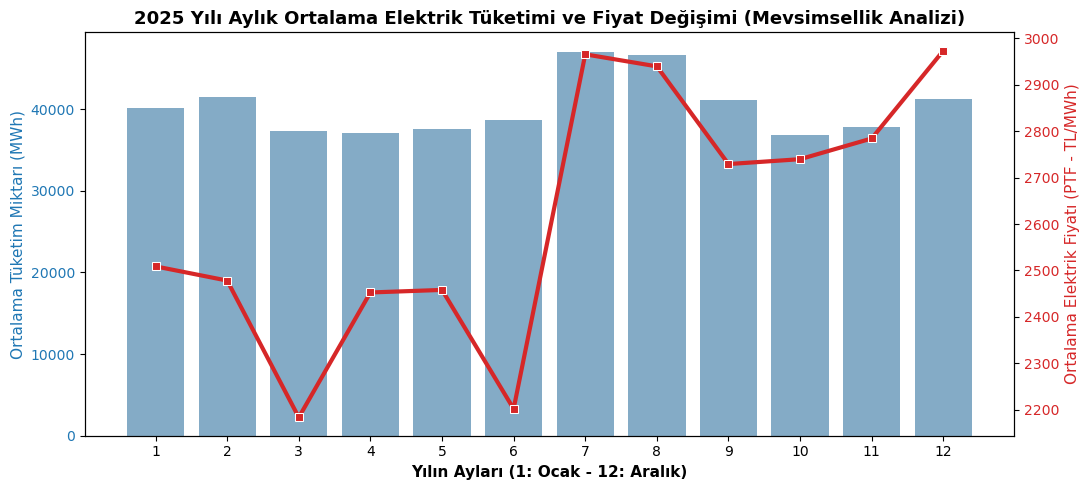

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aylık ortalama tüketim ve fiyat değerlerini hesaplayalım
aylik_veriler = df_final.groupby('Ay')[['Tüketim Miktarı(MWh)', 'PTF (TL/MWh)']].mean().reset_index()

# 2. Çift eksenli grafikle aylık değişimi çizelim
fig, ax1 = plt.subplots(figsize=(11, 5))

# Mavi Barlar: Aylık Ortalama Tüketim
color = 'tab:blue'
ax1.set_xlabel('Yılın Ayları (1: Ocak - 12: Aralık)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Ortalama Tüketim Miktarı (MWh)', color=color, fontsize=11)
sns.barplot(data=aylik_veriler, x='Ay', y='Tüketim Miktarı(MWh)', ax=ax1, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

# Kırmızı Çizgi: Aylık Ortalama Fiyat (PTF)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Ortalama Elektrik Fiyatı (PTF - TL/MWh)', color=color, fontsize=11)
sns.lineplot(data=aylik_veriler, x=aylik_veriler.index, y='PTF (TL/MWh)', ax=ax2, color=color, marker='s', linewidth=3)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("2025 Yılı Aylık Ortalama Elektrik Tüketimi ve Fiyat Değişimi (Mevsimsellik Analizi)", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

In [13]:
# --- AŞAMA 5: FİNANSAL SİMÜLASYON VE TASARRUF ANALİZİ ---

# 1. Fabrikanın saatlik ortalama 50 MWh elektrik tükettiğini varsayalım (Örnek bir endüstriyel tesis)
fabrika_saatlik_tuketim = 50 

# 2. Test setindeki gerçek fiyatlar üzerinden fabrikanın mevcut ham maliyetini hesaplayalım
# Mevcut durumda fabrika her saat sabit 50 MWh tüketiyor
mevcut_maliyet = y_test * fabrika_saatlik_tuketim

# 3. YÜK KAYDIRMA SİMÜLASYONU (Stratejik Karar)
# Modelimizin pik bulduğu akşam saatlerinde (17, 18, 19, 20) tüketimi %20 azaltıyoruz (40 MWh'e düşüyor)
# Azalttığımız bu toplam enerjiyi fiyatların en ucuz olduğu gece saatlerine (1, 2, 3, 4) ekliyoruz (60 MWh'e çıkıyor)

yeni_tuketim_listesi = []

for idx, row in X_test.iterrows():
    saat = row['Saat']
    if saat in [17, 18, 19, 20]:
        yeni_tuketim_listesi.append(fabrika_saatlik_tuketim * 0.80) # %20 Tasarruf/Kısıntı
    elif saat in [1, 2, 3, 4]:
        yeni_tuketim_listesi.append(fabrika_saatlik_tuketim * 1.20) # Geceye kaydırma
    else:
        yeni_tuketim_listesi.append(fabrika_saatlik_tuketim) # Diğer saatler normal tüketim

# 4. Yeni Stratejiye Göre Oluşan Finansal Maliyet
yeni_maliyet = y_test * yeni_tuketim_listesi

# 5. Sonuçların Hesaplanması
toplam_mevcut_maliyet = mevcut_maliyet.sum()
toplam_yeni_maliyet = yeni_maliyet.sum()
net_tasarruf_tl = toplam_mevcut_maliyet - toplam_yeni_maliyet
tasarruf_yuzdesi = (net_tasarruf_tl / toplam_mevcut_maliyet) * 100

print("--- AŞAMA 5: FİNANSAL SİMÜLASYON SONUÇLARI ---")
print(f"Fabrikanın Eski Stratejiyle Toplam Elektrik Maliyeti: {toplam_mevcut_maliyet:,.2f} TL")
print(f"YBS Modelimizle Yük Kaydırma Sonrası Yeni Maliyeti: {toplam_yeni_maliyet:,.2f} TL")
print(f"💰 MODELİN FABRİKAYA SAĞLADIĞI NET FİNANSAL TASARRUF: {net_tasarruf_tl:,.2f} TL")
print(f"📈 Enerji Maliyetinde Yüzdesel Azalma: %{tasarruf_yuzdesi:.2f}")

--- AŞAMA 5: FİNANSAL SİMÜLASYON SONUÇLARI ---
Fabrikanın Eski Stratejiyle Toplam Elektrik Maliyeti: 231,038,411.50 TL
YBS Modelimizle Yük Kaydırma Sonrası Yeni Maliyeti: 229,573,981.30 TL
💰 MODELİN FABRİKAYA SAĞLADIĞI NET FİNANSAL TASARRUF: 1,464,430.20 TL
📈 Enerji Maliyetinde Yüzdesel Azalma: %0.63


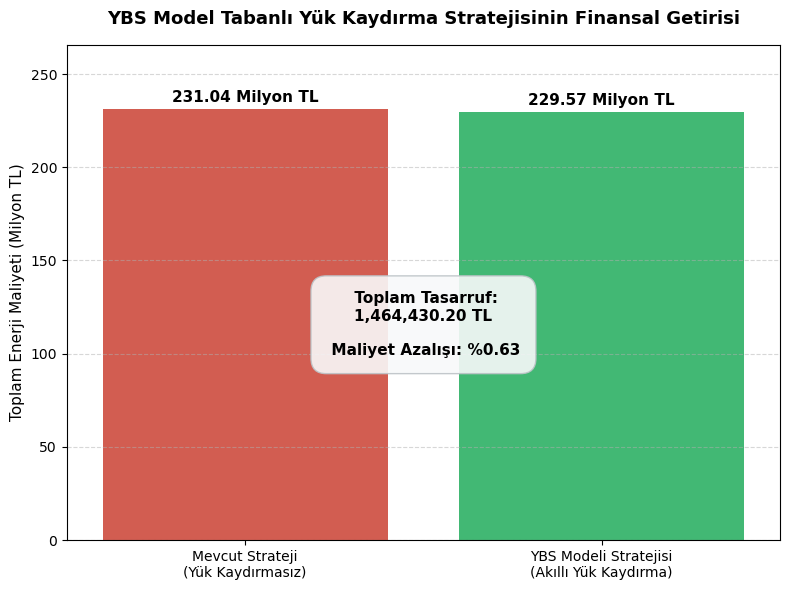

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grafik için verileri hazırlayalım
stratejiler = ['Mevcut Strateji\n(Yük Kaydırmasız)', 'YBS Modeli Stratejisi\n(Akıllı Yük Kaydırma)']
maliyetler = [toplam_mevcut_maliyet / 1e6, toplam_yeni_maliyet / 1e6] # Milyon TL cinsinden göstermek için

# 2. Grafik Çizimi
plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71'] # Eski maliyet kırmızı, yeni tasarruflu maliyet yeşil

barplot = sns.barplot(x=stratejiler, y=maliyetler, palette=colors, hue=stratejiler, legend=False)

# 3. Barların üzerine net tutarları yazdıralım
for bar in barplot.patches:
    y_val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, y_val + (max(maliyetler)*0.01), 
             f'{y_val:.2f} Milyon TL', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Grafik Başlıkları ve Düzenlemeler
plt.title('YBS Model Tabanlı Yük Kaydırma Stratejisinin Finansal Getirisi', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Toplam Enerji Maliyeti (Milyon TL)', fontsize=11)
plt.ylim(0, max(maliyetler) * 1.15) # Üstten biraz boşluk bırakalım yazılar sığsın diye
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Net kazanç bilgisini grafiğin üzerine not olarak ekleyelim
plt.text(0.5, max(maliyetler) * 0.5, 
         f' Toplam Tasarruf:\n{net_tasarruf_tl:,.2f} TL\n\n Maliyet Azalışı: %{tasarruf_yuzdesi:.2f}', 
         ha='center', va='center', color='black', 
         bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#bdc3c7', alpha=0.9),
         fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()